In [112]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(67)

In [113]:
class NN(torch.nn.Module):
    def __init__(self, input_dim, output_dim, layers, neurons, activation = 'tanh'):
        super(NN, self).__init__()
        self.activation = activation

        self.input_layer   = torch.nn.Linear(input_dim, neurons, bias = True)
        self.hidden_layers = torch.nn.ModuleList([torch.nn.Linear(neurons, neurons, bias = True) for _ in range(layers)])
        self.output_layer  = torch.nn.Linear(neurons, output_dim, bias = True)
        
        self.act           = torch.nn.Tanh()
    
    def forward(self, x):
        a =  self.input_layer(x)
        for l in self.hidden_layers:
            a = self.act(l(a))
        return self.output_layer(a)
    
    
    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain(self.activation)
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                m.bias.data.fill_(0)
        self.apply(init_weights)

sum(p.numel() for p in NN(5, 5, 5, 5).parameters())

210

In [114]:
BATCH_SIZE = 32
EPOCHS  = 50

In [115]:
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

class dataset(torch.utils.data.Dataset):
    def __init__(self, engine: torch.quasirandom.SobolEngine, draw: int):
        self.data = engine.draw(draw) 

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]
    
train_dataset_obj = dataset(sobol_engine, 10_000)
train_dataloader = torch.utils.data.DataLoader(train_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

test_dataset_obj = dataset(sobol_engine, 1000)
test_dataloader = torch.utils.data.DataLoader(test_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

In [116]:
def f(x):
    return torch.sin(x)

def g(t):
    return torch.sin(t)

domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]

def get_initial(data):
    data = data.clone()
    data[:,0] = domain[0][0] + (domain[0][1] - domain[0][0]) * data[:,0]

    data[:, 1] = 0 # t = 0 

    x = data[:,0]
    u = f(x)

    u = torch.stack((u, torch.zeros_like(u)), dim=1)

    return u


def get_BC(data):
    data = data.clone()
    data[:,1] = domain[1][0] + (domain[1][1] - domain[1][0]) * data[:,1]

    t = data[:,1]

    # x = 0
    data_0 = data.clone()
    data_0[:,0] = domain[0][0]
    u_0 = g(t)

    # x = L
    data_L = data.clone()
    data_L[:,0] = domain[0][1]
    u_L = g(t)

    return data_0, data_L, u_0, u_L

def get_interior(data): # returns x (location)
    data = data.clone()
    data[:, 0] =  domain[0][0] + (domain[0][1] - domain[0][0]) * data[:, 0]
    data[:, 1] =  domain[1][0] + (domain[1][1] - domain[1][0]) * data[:, 1]
    return data

get_BC(next(iter(train_dataloader)))

(tensor([[0.0000, 1.9490],
         [0.0000, 0.1731],
         [0.0000, 0.3799],
         [0.0000, 1.7505],
         [0.0000, 0.0984],
         [0.0000, 1.0803],
         [0.0000, 1.4768],
         [0.0000, 0.1763],
         [0.0000, 0.8386],
         [0.0000, 1.9865],
         [0.0000, 1.0745],
         [0.0000, 0.7472],
         [0.0000, 0.1714],
         [0.0000, 0.1388],
         [0.0000, 0.9943],
         [0.0000, 1.7292],
         [0.0000, 1.9944],
         [0.0000, 1.8907],
         [0.0000, 0.1277],
         [0.0000, 1.6660],
         [0.0000, 0.1301],
         [0.0000, 0.7097],
         [0.0000, 1.3829],
         [0.0000, 1.0490],
         [0.0000, 0.6389],
         [0.0000, 0.9552],
         [0.0000, 0.4368],
         [0.0000, 0.3530],
         [0.0000, 0.3494],
         [0.0000, 1.8516],
         [0.0000, 1.7581],
         [0.0000, 1.0959]]),
 tensor([[1.0000, 1.9490],
         [1.0000, 0.1731],
         [1.0000, 0.3799],
         [1.0000, 1.7505],
         [1.0000, 0.0984],

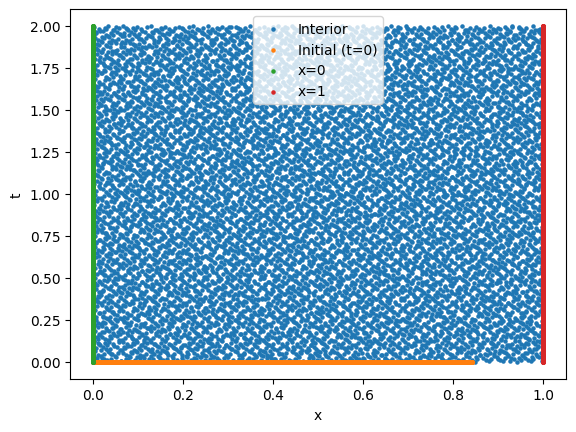

In [117]:
dummy_data = []

for d in train_dataloader:
    dummy_data.append(d)
    
data = torch.cat(dummy_data, dim = 0)

interior = get_interior(data)
ic = get_initial(data)
bc_0, bc_L, u_0, u_L = get_BC(data)

plt.figure()
plt.scatter(interior[:,0], interior[:,1], s=5, label="Interior")
plt.scatter(ic[:,0], ic[:,1], s=5, label="Initial (t=0)")

plt.scatter(bc_0[:,0], bc_0[:,1], s=5, label="x=0")
plt.scatter(bc_L[:,0], bc_L[:,1], s=5, label="x=1")

plt.legend()
plt.xlabel("x")
plt.ylabel("t")
plt.show()

In [118]:
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 4, neurons = 20)

def get_interior_residual(u_model, points, alpha, epsilon):
    points.requires_grad = True

    u = u_model(points)

    grad_u = torch.autograd.grad(u.sum(), points, create_graph = True)[0]
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]
    u_xx = torch.autograd.grad(u_x.sum(), points, create_graph=True)[0][:, 0]

    interior_residual = u_t + (alpha * u_x) - (epsilon * u_xx)

    return interior_residual.unsqueeze(1)

In [119]:
interior_data = get_interior(next(iter(train_dataloader)))
get_interior_residual(u_predictor_model, interior_data, 1, 1).shape

torch.Size([32, 1])

In [120]:
def get_IC_residue(u_model, points, f):

    u_0_data = points.clone().detach().requires_grad_(True) # u at t = 0

    u = u_model(u_0_data) 
    ic_1_residue = u - f(u_0_data[:, 0].unsqueeze(1))

    return ic_1_residue

IC_data = get_initial(next(iter(train_dataloader))) # u, u_t (exact at t = 0)
get_IC_residue(u_predictor_model, IC_data, f).shape


torch.Size([32, 1])

In [121]:
def get_BC_residue(u_model, points, g):
    return (u_model(points[0]) - g(points[2].unsqueeze(1))) + (u_model(points[1]) - g(points[3].unsqueeze(1)))


BC_data = get_BC(next(iter(train_dataloader))) 
get_BC_residue(u_predictor_model, BC_data, g).shape

torch.Size([32, 1])

In [122]:
optimizer = torch.optim.Adam(
    list(u_predictor_model.parameters()),
    lr=1e-3
)

alpha = 0.1
epsilon = 10

epoch_loss_track = []
epoch_loss_track_test = []


for epoch in range(EPOCHS):
    
    epoch_loss = 0
    epoch_loss_test = 0

    for train_data in train_dataloader:
        u_predictor_model.train()


        optimizer.zero_grad()
        interior_data = get_interior(train_data) 
        IC_data       = get_initial(train_data) 
        BC_data       = get_BC(train_data)


        interior_residue  = get_interior_residual(u_predictor_model, interior_data, alpha, epsilon)
        IC_residue        = get_IC_residue(u_predictor_model, IC_data, f)
        BC_residue        = get_BC_residue(u_predictor_model, BC_data, g)

        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
        loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))

        # total
        loss = loss_pde + loss_ic + loss_bc
        epoch_loss += loss
        loss.backward()
        optimizer.step()

    for test_data in test_dataloader:
        
        u_predictor_model.eval()

        interior_data = get_interior(test_data) 
        IC_data       = get_initial(test_data) 
        BC_data       = get_BC(test_data)

        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))
        loss_bc  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))

        # total
        loss = loss_pde + loss_ic + loss_bc
        epoch_loss_test += loss
    
    epoch_loss = epoch_loss / len(train_dataloader)
    epoch_loss_track.append(epoch_loss.item())

    epoch_loss_test = epoch_loss_test / len(test_dataloader)
    epoch_loss_track_test.append(epoch_loss_test.item())


    if epoch % 10 == 0:
        print(f"EPOCH: {epoch} | train loss: {epoch_loss.item():.4f} | test loss: {epoch_loss_test.item():.4f}")

EPOCH: 0 | train loss: 0.5631 | test loss: 0.3911
EPOCH: 10 | train loss: 0.0920 | test loss: 0.0460
EPOCH: 20 | train loss: 0.0554 | test loss: 0.0146
EPOCH: 30 | train loss: 0.0265 | test loss: 0.0044
EPOCH: 40 | train loss: 0.0163 | test loss: 0.0242


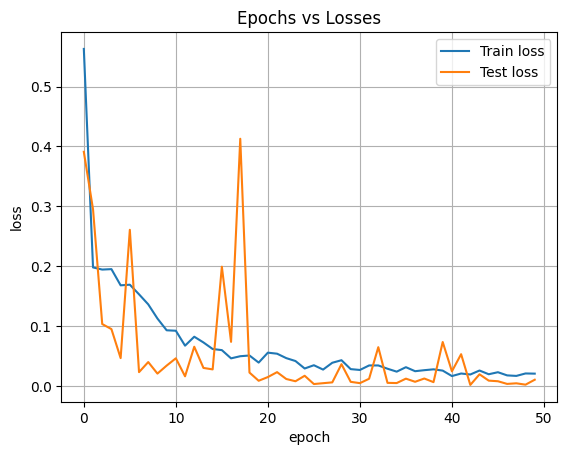

In [123]:
plt.plot(epoch_loss_track, label = "Train loss")
plt.plot(epoch_loss_track_test, label = "Test loss")

plt.title("Epochs vs Losses")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

plt.show()

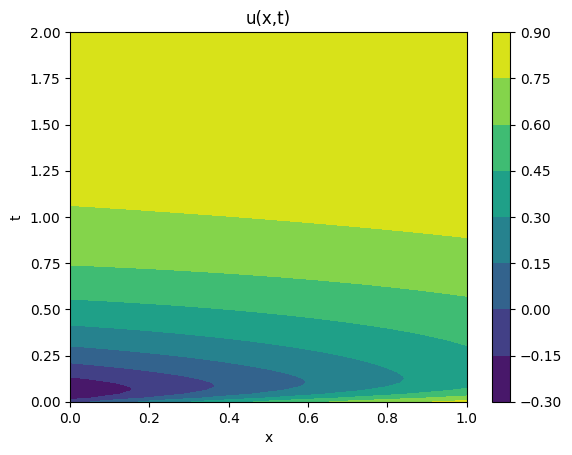

In [124]:
x_s = torch.linspace(domain[0][0], domain[0][1], 100)
t_s = torch.linspace(domain[1][0], domain[1][1], 100)

X, T = torch.meshgrid(x_s, t_s, indexing='ij')

points = torch.stack((X.flatten(), T.flatten()), dim=1)
points = points.clone().detach().requires_grad_(True)

u = u_predictor_model(points)

U = u.reshape(100, 100).detach().numpy()
plt.contourf(X.detach().numpy(), T.detach().numpy(), U)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("u(x,t)")
plt.show()
